<a href="https://colab.research.google.com/github/ganm30261-hub/VideoRecSys/blob/main/notebooks/step2_recall_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Scalable Video Recommendation System
## Step 2: Two-Tower Recall Model（双塔召回）

---
**本 Notebook 完成**:
```
Cell 1  → 安装依赖（含 FAISS）
Cell 2  → 加载 Step 1 产出的特征和样本
Cell 3  → 数据集封装（PyTorch Dataset）
Cell 4  → 双塔模型定义（User Tower + Item Tower）
Cell 5  → In-batch Negative 对比学习 Loss
Cell 6  → 训练循环（含 Early Stopping）
Cell 7  → 训练过程可视化
Cell 8  → 生成全量 Embedding
Cell 9  → FAISS 向量索引构建
Cell 10 → 召回效果评估（Recall@K / Hit@K / NDCG@K）
Cell 11 → 对比 Baseline（随机召回 / 热门召回）
Cell 12 → Embedding 写入 Feature Store
Cell 13 → Step 2 完成报告
```

> 💡 **建议**: 运行时 → 更改运行时类型 → GPU (T4)，训练速度提升 10x

---
## Cell 1 — 安装依赖

In [2]:
!pip install -q torch torchvision faiss-cpu pyarrow pandas numpy scikit-learn tqdm tabulate matplotlib
print('✅ 依赖安装完成')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.5 MB/s eta 0:00:00
✅ 依赖安装完成


---
## Cell 2 — 配置 & 加载 Step 1 数据

In [3]:
import os, time, logging, warnings, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
warnings.filterwarnings('ignore')

# ── 路径（与 Step 1 保持一致）──
USE_GDRIVE = True   # 如果 Step 1 用了 Google Drive，改为 True
if USE_GDRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/VideoRecSys'
else:
    BASE_DIR = '/content/VideoRecSys'

PATHS = {
    'cleaned'      : f'{BASE_DIR}/data/cleaned',
    'features'     : f'{BASE_DIR}/data/features',
    'samples'      : f'{BASE_DIR}/data/samples',
    'feature_store': f'{BASE_DIR}/feature_store',
    'models'       : f'{BASE_DIR}/models/recall',
    'logs'         : f'{BASE_DIR}/logs',
    'reports'      : f'{BASE_DIR}/reports',
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)

# ── 超参数 ──
CFG = {
    'embedding_dim'  : 64,       # 用户/视频向量维度
    'hidden_layers'  : [256, 128, 64],
    'dropout'        : 0.2,
    'temperature'    : 0.07,     # 对比学习温度
    'lr'             : 1e-3,
    'batch_size'     : 1024,
    'epochs'         : 20,
    'early_stop'     : 3,        # 连续N个epoch不提升则停止
    'top_k'          : [10, 20, 50],  # 评估用的 K 值
    'faiss_top_k'    : 200,      # 召回候选数
    'seq_len'        : 50,
    'random_seed'    : 42,
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
}
torch.manual_seed(CFG['random_seed'])
np.random.seed(CFG['random_seed'])

# ── Logger ──
def get_logger():
    logger = logging.getLogger('Step2')
    logger.setLevel(logging.INFO)
    if logger.handlers: logger.handlers.clear()
    ch = logging.StreamHandler()
    ch.setFormatter(logging.Formatter('[%(asctime)s] %(message)s', '%H:%M:%S'))
    logger.addHandler(ch)
    return logger
log = get_logger()

class Timer:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t = time.time(); log.info(f'▶ {self.name}'); return self
    def __exit__(self, *a): log.info(f'✅ {self.name} 完成  {time.time()-self.t:.1f}s')

# ── 加载数据 ──
with Timer('加载 Step 1 数据'):
    train_df  = pd.read_parquet(f"{PATHS['samples']}/train.parquet")
    test_df   = pd.read_parquet(f"{PATHS['samples']}/test.parquet")
    user_feat = pd.read_parquet(f"{PATHS['features']}/user_features.parquet")
    item_feat = pd.read_parquet(f"{PATHS['features']}/item_features.parquet")
    seq_df    = pd.read_parquet(f"{PATHS['features']}/user_sequences.parquet")

log.info(f'训练集: {len(train_df):,}  测试集: {len(test_df):,}')
log.info(f'用户数: {user_feat.shape[0]:,}  视频数: {item_feat.shape[0]:,}')
log.info(f'设备:   {CFG["device"]}')

Mounted at /content/drive


[22:33:54] ▶ 加载 Step 1 数据
INFO:Step2:▶ 加载 Step 1 数据
[22:34:24] ✅ 加载 Step 1 数据 完成  30.2s
INFO:Step2:✅ 加载 Step 1 数据 完成  30.2s
[22:34:24] 训练集: 2,343,380  测试集: 202,150
INFO:Step2:训练集: 2,343,380  测试集: 202,150
[22:34:24] 用户数: 6,040  视频数: 3,260
INFO:Step2:用户数: 6,040  视频数: 3,260
[22:34:24] 设备:   cuda
INFO:Step2:设备:   cuda


---
## Cell 3 — 特征预处理 & Dataset 封装

In [4]:
# ── ID 重新映射（从 0 开始，方便 Embedding 层）──
all_users = sorted(user_feat['user_id'].unique())
all_items = sorted(item_feat['item_id'].unique())
user2idx  = {u: i for i, u in enumerate(all_users)}
item2idx  = {v: i for i, v in enumerate(all_items)}
idx2item  = {i: v for v, i in item2idx.items()}

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)
log.info(f'用户数: {N_USERS}  视频数: {N_ITEMS}')

# ── 数值特征列（排除 ID 和字符串列）──
USER_FEAT_COLS = [c for c in user_feat.columns
                  if c not in ['user_id'] and user_feat[c].dtype in [np.float64, np.float32,
                                                                       np.int64, np.int32, int, float]]
ITEM_FEAT_COLS = [c for c in item_feat.columns
                  if c not in ['item_id'] and item_feat[c].dtype in [np.float64, np.float32,
                                                                       np.int64, np.int32, int, float]]

log.info(f'用户侧数值特征: {len(USER_FEAT_COLS)} 个  {USER_FEAT_COLS[:5]}...')
log.info(f'视频侧数值特征: {len(ITEM_FEAT_COLS)} 个  {ITEM_FEAT_COLS[:5]}...')

# ── 特征归一化（MinMax，只在训练集上 fit）──
from sklearn.preprocessing import MinMaxScaler

user_scaler = MinMaxScaler()
item_scaler = MinMaxScaler()

user_feat_np = user_feat[USER_FEAT_COLS].fillna(0).values.astype(np.float32)
item_feat_np = item_feat[ITEM_FEAT_COLS].fillna(0).values.astype(np.float32)

user_feat_np = user_scaler.fit_transform(user_feat_np)
item_feat_np = item_scaler.fit_transform(item_feat_np)

# 建立快速查找字典
user_feat_dict = {uid: user_feat_np[i] for i, uid in enumerate(user_feat['user_id'])}
item_feat_dict = {iid: item_feat_np[i] for i, iid in enumerate(item_feat['item_id'])}

# 序列字典
seq_dict = {}
for _, row in seq_df.iterrows():
    raw = str(row.get('pos_seq', '') or '')
    ids = [item2idx[int(x)] for x in raw.split(',') if x and int(x) in item2idx]
    seq_dict[row['user_id']] = ids

log.info('特征预处理完成 ✓')

[22:35:06] 用户数: 6040  视频数: 3260
INFO:Step2:用户数: 6040  视频数: 3260
[22:35:06] 用户侧数值特征: 14 个  ['interaction_count', 'avg_rating', 'std_rating', 'min_rating', 'max_rating']...
INFO:Step2:用户侧数值特征: 14 个  ['interaction_count', 'avg_rating', 'std_rating', 'min_rating', 'max_rating']...
[22:35:06] 视频侧数值特征: 25 个  ['play_count', 'avg_rating', 'std_rating', 'ctr_proxy', 'unique_users']...
INFO:Step2:视频侧数值特征: 25 个  ['play_count', 'avg_rating', 'std_rating', 'ctr_proxy', 'unique_users']...
[22:35:08] 特征预处理完成 ✓
INFO:Step2:特征预处理完成 ✓


In [5]:
# ── PyTorch Dataset ──
class RecDataset(Dataset):
    """
    每条样本: (user_idx, item_idx, label, user_feat_vec, item_feat_vec, seq_tensor)
    对应企业: 实时从 Feature Store 读取特征
    """
    def __init__(self, df, user2idx, item2idx, user_feat_dict, item_feat_dict,
                 seq_dict, seq_len=50, only_positive=False):
        # 双塔训练只用正样本（对比学习范式）
        if only_positive:
            df = df[df['label'] == 1].copy()
        self.df = df.reset_index(drop=True)
        self.user2idx = user2idx
        self.item2idx = item2idx
        self.u_feat   = user_feat_dict
        self.i_feat   = item_feat_dict
        self.seq_dict = seq_dict
        self.seq_len  = seq_len
        self.u_dim    = len(next(iter(user_feat_dict.values())))
        self.i_dim    = len(next(iter(item_feat_dict.values())))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        uid     = row['user_id']
        iid     = row['item_id']
        label   = float(row['label'])
        u_idx   = self.user2idx.get(uid, 0)
        i_idx   = self.item2idx.get(iid, 0)

        # 用户数值特征
        u_vec = self.u_feat.get(uid, np.zeros(self.u_dim, dtype=np.float32))
        # 视频数值特征
        i_vec = self.i_feat.get(iid, np.zeros(self.i_dim, dtype=np.float32))

        # 行为序列（padding / truncating）
        seq = self.seq_dict.get(uid, [])
        seq = seq[-self.seq_len:]
        pad_len = self.seq_len - len(seq)
        seq_pad = [0] * pad_len + seq

        return (
            torch.tensor(u_idx,   dtype=torch.long),
            torch.tensor(i_idx,   dtype=torch.long),
            torch.tensor(label,   dtype=torch.float),
            torch.tensor(u_vec,   dtype=torch.float),
            torch.tensor(i_vec,   dtype=torch.float),
            torch.tensor(seq_pad, dtype=torch.long),
        )


# 双塔训练只用正样本，通过 In-batch Negative 构造负样本
train_ds = RecDataset(train_df, user2idx, item2idx, user_feat_dict, item_feat_dict,
                      seq_dict, CFG['seq_len'], only_positive=True)
test_ds  = RecDataset(test_df,  user2idx, item2idx, user_feat_dict, item_feat_dict,
                      seq_dict, CFG['seq_len'], only_positive=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

log.info(f'训练集正样本: {len(train_ds):,}  测试样本: {len(test_ds):,}')
log.info(f'用户特征维度: {train_ds.u_dim}  视频特征维度: {train_ds.i_dim}')

[22:35:17] 训练集正样本: 468,676  测试样本: 202,150
INFO:Step2:训练集正样本: 468,676  测试样本: 202,150
[22:35:17] 用户特征维度: 14  视频特征维度: 25
INFO:Step2:用户特征维度: 14  视频特征维度: 25


---
## Cell 4 — 双塔模型定义

In [6]:
# ============================================================
# 双塔模型 (Two-Tower DSSM)
#
# 架构:
#   User Tower:
#     用户 ID Embedding
#     + 用户数值特征
#     + 行为序列平均池化 (Mean Pooling)
#     → MLP → L2归一化 → 用户向量
#
#   Item Tower:
#     视频 ID Embedding
#     + 视频数值特征
#     → MLP → L2归一化 → 视频向量
#
# Loss: In-batch Negative Sampling + InfoNCE
# 对应: 阿里/快手 工业双塔标准实现
# ============================================================

def build_mlp(input_dim, hidden_layers, output_dim, dropout):
    """通用 MLP 构建"""
    layers = []
    dims = [input_dim] + hidden_layers + [output_dim]
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:  # 最后一层不加激活
            layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)


class UserTower(nn.Module):
    """
    用户塔
    输入: 用户ID + 数值特征 + 行为序列
    输出: L2归一化的用户向量 [B, embedding_dim]
    """
    def __init__(self, n_users, n_items, u_feat_dim,
                 id_embed_dim=32, hidden=[256,128,64],
                 out_dim=64, dropout=0.2, seq_len=50):
        super().__init__()
        self.user_emb = nn.Embedding(n_users + 1, id_embed_dim, padding_idx=0)
        self.item_emb = nn.Embedding(n_items + 1, id_embed_dim, padding_idx=0)  # 序列用

        # 输入维度 = 用户ID向量 + 数值特征 + 序列平均池化向量
        input_dim = id_embed_dim + u_feat_dim + id_embed_dim
        self.mlp = build_mlp(input_dim, hidden, out_dim, dropout)

    def forward(self, user_idx, u_feat, seq_idx):
        # 用户 ID Embedding
        u_id_vec = self.user_emb(user_idx)            # [B, id_dim]

        # 行为序列 Mean Pooling
        seq_emb  = self.item_emb(seq_idx)             # [B, seq_len, id_dim]
        mask     = (seq_idx != 0).float().unsqueeze(-1)  # [B, seq_len, 1]
        seq_sum  = (seq_emb * mask).sum(dim=1)        # [B, id_dim]
        seq_cnt  = mask.sum(dim=1).clamp(min=1)       # [B, 1]
        seq_pool = seq_sum / seq_cnt                  # [B, id_dim]

        # 拼接所有输入
        x = torch.cat([u_id_vec, u_feat, seq_pool], dim=-1)
        out = self.mlp(x)                             # [B, out_dim]
        return F.normalize(out, dim=-1)               # L2 归一化


class ItemTower(nn.Module):
    """
    视频塔
    输入: 视频ID + 数值特征
    输出: L2归一化的视频向量 [B, embedding_dim]
    """
    def __init__(self, n_items, i_feat_dim,
                 id_embed_dim=32, hidden=[256,128,64],
                 out_dim=64, dropout=0.2):
        super().__init__()
        self.item_emb = nn.Embedding(n_items + 1, id_embed_dim, padding_idx=0)
        input_dim = id_embed_dim + i_feat_dim
        self.mlp = build_mlp(input_dim, hidden, out_dim, dropout)

    def forward(self, item_idx, i_feat):
        i_id_vec = self.item_emb(item_idx)            # [B, id_dim]
        x        = torch.cat([i_id_vec, i_feat], dim=-1)
        out      = self.mlp(x)
        return F.normalize(out, dim=-1)


class TwoTowerModel(nn.Module):
    """
    双塔召回模型
    训练时: 两塔同时前向，计算对比 Loss
    推理时: 两塔独立前向，分别生成 Embedding
    """
    def __init__(self, n_users, n_items, u_feat_dim, i_feat_dim, cfg):
        super().__init__()
        emb_dim    = cfg['embedding_dim']
        hidden     = cfg['hidden_layers']
        dropout    = cfg['dropout']
        self.tau   = cfg['temperature']  # 温度系数

        self.user_tower = UserTower(
            n_users, n_items, u_feat_dim,
            id_embed_dim=32, hidden=hidden,
            out_dim=emb_dim, dropout=dropout,
            seq_len=cfg['seq_len']
        )
        self.item_tower = ItemTower(
            n_items, i_feat_dim,
            id_embed_dim=32, hidden=hidden,
            out_dim=emb_dim, dropout=dropout
        )

    def forward(self, user_idx, item_idx, u_feat, i_feat, seq_idx):
        user_vec = self.user_tower(user_idx, u_feat, seq_idx)  # [B, D]
        item_vec = self.item_tower(item_idx, i_feat)           # [B, D]
        return user_vec, item_vec

    def get_user_embedding(self, user_idx, u_feat, seq_idx):
        return self.user_tower(user_idx, u_feat, seq_idx)

    def get_item_embedding(self, item_idx, i_feat):
        return self.item_tower(item_idx, i_feat)


# ── 初始化模型 ──
model = TwoTowerModel(
    n_users=N_USERS, n_items=N_ITEMS,
    u_feat_dim=train_ds.u_dim,
    i_feat_dim=train_ds.i_dim,
    cfg=CFG
).to(CFG['device'])

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info(f'模型总参数: {total_params:,}  可训练: {trainable:,}')
print(model)

[22:35:21] 模型总参数: 529,504  可训练: 529,504
INFO:Step2:模型总参数: 529,504  可训练: 529,504


TwoTowerModel(
  (user_tower): UserTower(
    (user_emb): Embedding(6041, 32, padding_idx=0)
    (item_emb): Embedding(3261, 32, padding_idx=0)
    (mlp): Sequential(
      (0): Linear(in_features=78, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.2, inplace=False)
      (12): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (item_tower): ItemTower(
    (item_emb): Embedding(3261, 32, padding_idx=0)
    (mlp): Sequential(
      (0): Line

---
## Cell 5 — Loss 函数（In-batch Negative InfoNCE）

In [7]:
# ============================================================
# In-batch Negative Sampling + InfoNCE Loss
#
# 原理:
#   - batch 内每个用户的正样本视频 = 正例
#   - batch 内其他所有视频 = 负例（无需额外采样）
#   - 相似度矩阵: [B, B]，对角线是正例分数
#   - 最大化正例相似度，最小化负例相似度
#
# 这是工业双塔标准 Loss，来自 Google 2021 论文
# ============================================================

class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.tau = temperature

    def forward(self, user_vec, item_vec):
        """
        user_vec: [B, D] L2归一化
        item_vec: [B, D] L2归一化
        """
        # 相似度矩阵 [B, B]，对角线是正例
        logits = torch.matmul(user_vec, item_vec.T) / self.tau  # [B, B]

        # 标签: 对角线是正例（index 0,1,2,...,B-1）
        labels = torch.arange(logits.size(0), device=logits.device)

        # 双向对比 Loss（用户 → 视频 + 视频 → 用户）
        loss_u2i = F.cross_entropy(logits,   labels)
        loss_i2u = F.cross_entropy(logits.T, labels)
        return (loss_u2i + loss_i2u) / 2


loss_fn   = InfoNCELoss(temperature=CFG['temperature'])
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5
)

log.info(f'Loss: InfoNCE  温度: {CFG["temperature"]}')
log.info(f'优化器: Adam  lr={CFG["lr"]}  调度: CosineAnnealing')

[22:35:36] Loss: InfoNCE  温度: 0.07
INFO:Step2:Loss: InfoNCE  温度: 0.07
[22:35:36] 优化器: Adam  lr=0.001  调度: CosineAnnealing
INFO:Step2:优化器: Adam  lr=0.001  调度: CosineAnnealing


---
## Cell 6 — 训练循环（含 Early Stopping）

In [8]:
# ============================================================
# 训练循环
# 含: Early Stopping / 模型保存 / 指标记录
# ============================================================
from tqdm import tqdm

def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, n_batch = 0.0, 0
    for batch in loader:
        u_idx, i_idx, label, u_feat, i_feat, seq = [b.to(device) for b in batch]

        # 只用正样本训练（label==1）
        # Dataset already filtered, all are positive
        user_vec, item_vec = model(u_idx, i_idx, u_feat, i_feat, seq)
        loss = loss_fn(user_vec, item_vec)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
        optimizer.step()

        total_loss += loss.item()
        n_batch    += 1
    return total_loss / n_batch


def eval_epoch(model, loader, loss_fn, device):
    """验证集 Loss（用测试集正样本估算）"""
    model.eval()
    total_loss, n_batch = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            u_idx, i_idx, label, u_feat, i_feat, seq = [b.to(device) for b in batch]
            mask = label == 1
            if mask.sum() < 2: continue
            user_vec, item_vec = model(
                u_idx[mask], i_idx[mask],
                u_feat[mask], i_feat[mask], seq[mask]
            )
            loss = loss_fn(user_vec, item_vec)
            total_loss += loss.item()
            n_batch    += 1
    return total_loss / max(n_batch, 1)


# ── 主训练循环 ──
history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss = float('inf')
no_improve    = 0
CKPT_PATH = f"{PATHS['models']}/two_tower_best.pt"

log.info(f'开始训练  epochs={CFG["epochs"]}  batch={CFG["batch_size"]}  device={CFG["device"]}')
print()

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, CFG['device'])
    val_loss   = eval_epoch(model, test_loader, loss_fn, CFG['device'])
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    improved = '⬇ best' if val_loss < best_val_loss else ''
    print(f'Epoch {epoch:3d}/{CFG["epochs"]}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'lr={current_lr:.2e}  {time.time()-t0:.1f}s  {improved}')

    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'val_loss': val_loss, 'cfg': CFG}, CKPT_PATH)
    else:
        no_improve += 1
        if no_improve >= CFG['early_stop']:
            log.info(f'Early stopping at epoch {epoch}')
            break

# 加载最佳模型
ckpt = torch.load(CKPT_PATH, map_location=CFG['device'])
model.load_state_dict(ckpt['model'])
log.info(f'最佳模型已加载  epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

[22:35:44] 开始训练  epochs=20  batch=1024  device=cuda
INFO:Step2:开始训练  epochs=20  batch=1024  device=cuda



Epoch   1/20  train=6.9465  val=6.1901  lr=9.94e-04  129.7s  ⬇ best
Epoch   2/20  train=6.7858  val=6.0899  lr=9.76e-04  129.3s  ⬇ best
Epoch   3/20  train=6.6906  val=6.0612  lr=9.46e-04  126.0s  ⬇ best
Epoch   4/20  train=6.6345  val=6.0573  lr=9.05e-04  126.1s  ⬇ best
Epoch   5/20  train=6.5961  val=6.0560  lr=8.55e-04  125.1s  ⬇ best
Epoch   6/20  train=6.5679  val=6.0519  lr=7.96e-04  127.8s  ⬇ best
Epoch   7/20  train=6.5463  val=6.0491  lr=7.30e-04  125.9s  ⬇ best
Epoch   8/20  train=6.5273  val=6.0585  lr=6.58e-04  126.5s  
Epoch   9/20  train=6.5115  val=6.0585  lr=5.82e-04  128.1s  


[22:56:59] Early stopping at epoch 10
INFO:Step2:Early stopping at epoch 10
[22:56:59] 最佳模型已加载  epoch=7  val_loss=6.0491
INFO:Step2:最佳模型已加载  epoch=7  val_loss=6.0491


Epoch  10/20  train=6.4986  val=6.0520  lr=5.05e-04  129.2s  


---
## Cell 7 — 训练过程可视化

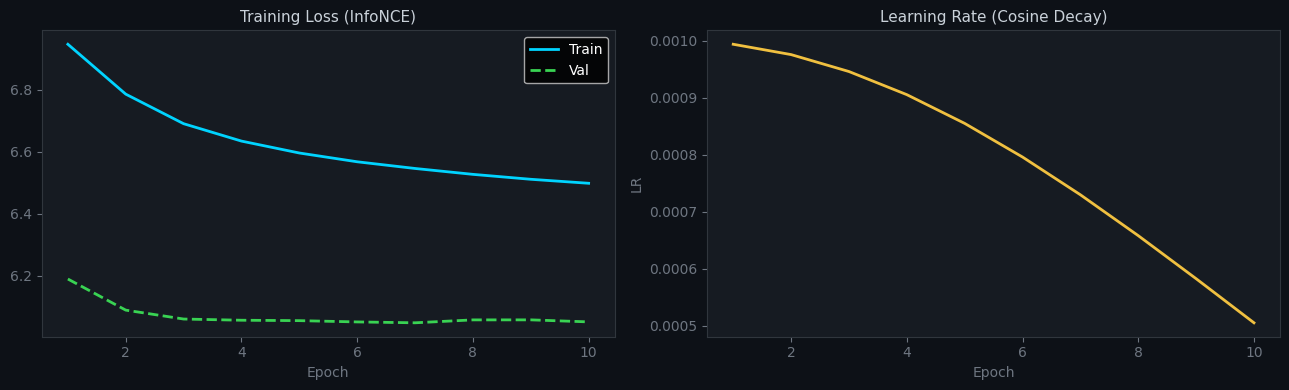

In [9]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')

def styled(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#c9d1d9', fontsize=11)
    ax.tick_params(colors='#6e7681')
    for s in ax.spines.values(): s.set_color('#30363d')

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss 曲线
styled(axes[0], 'Training Loss (InfoNCE)')
axes[0].plot(epochs_ran, history['train_loss'], '#00d4ff', lw=2, label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   '#39d353', lw=2, label='Val', linestyle='--')
axes[0].set_xlabel('Epoch', color='#6e7681')
axes[0].legend()

# 学习率曲线
styled(axes[1], 'Learning Rate (Cosine Decay)')
axes[1].plot(epochs_ran, history['lr'], '#f0c040', lw=2)
axes[1].set_xlabel('Epoch', color='#6e7681')
axes[1].set_ylabel('LR', color='#6e7681')

plt.tight_layout()
plt.savefig(f"{PATHS['reports']}/step2_training_curve.png", dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Cell 8 — 生成全量 Embedding

In [10]:
# ============================================================
# 生成全量 User / Item Embedding
# 对应企业: 每日离线任务，产出 Embedding 写入 Feature Store
# ============================================================

model.eval()
device = CFG['device']

def generate_item_embeddings(model, item_feat_dict, item2idx, i_feat_dim, batch_size=512, device='cpu'):
    """生成全量视频 Embedding"""
    all_item_ids  = list(item2idx.keys())
    all_item_idxs = [item2idx[i] for i in all_item_ids]
    embeddings    = []

    for start in tqdm(range(0, len(all_item_ids), batch_size), desc='Item Embeddings'):
        batch_ids  = all_item_ids[start:start+batch_size]
        batch_idxs = all_item_idxs[start:start+batch_size]

        i_idx  = torch.tensor(batch_idxs, dtype=torch.long).to(device)
        i_feat = torch.tensor(
            np.stack([item_feat_dict.get(i, np.zeros(i_feat_dim, np.float32)) for i in batch_ids]),
            dtype=torch.float
        ).to(device)

        with torch.no_grad():
            emb = model.get_item_embedding(i_idx, i_feat)
        embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings), all_item_ids


def generate_user_embeddings(model, user_feat_dict, seq_dict, user2idx, item2idx,
                              u_feat_dim, seq_len, batch_size=512, device='cpu'):
    """生成全量用户 Embedding"""
    all_user_ids  = list(user2idx.keys())
    all_user_idxs = [user2idx[u] for u in all_user_ids]
    embeddings    = []

    for start in tqdm(range(0, len(all_user_ids), batch_size), desc='User Embeddings'):
        batch_uids  = all_user_ids[start:start+batch_size]
        batch_uidxs = all_user_idxs[start:start+batch_size]

        u_idx  = torch.tensor(batch_uidxs, dtype=torch.long).to(device)
        u_feat = torch.tensor(
            np.stack([user_feat_dict.get(u, np.zeros(u_feat_dim, np.float32)) for u in batch_uids]),
            dtype=torch.float
        ).to(device)

        # 序列
        seqs = []
        for uid in batch_uids:
            seq = seq_dict.get(uid, [])
            seq = seq[-seq_len:]
            pad = [0] * (seq_len - len(seq)) + seq
            seqs.append(pad)
        seq_t = torch.tensor(seqs, dtype=torch.long).to(device)

        with torch.no_grad():
            emb = model.get_user_embedding(u_idx, u_feat, seq_t)
        embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings), all_user_ids


with Timer('生成全量 Embedding'):
    item_embs, item_ids = generate_item_embeddings(
        model, item_feat_dict, item2idx, train_ds.i_dim,
        batch_size=512, device=device
    )
    user_embs, user_ids = generate_user_embeddings(
        model, user_feat_dict, seq_dict, user2idx, item2idx,
        train_ds.u_dim, CFG['seq_len'],
        batch_size=512, device=device
    )

log.info(f'视频 Embedding: {item_embs.shape}  (norm={np.linalg.norm(item_embs[0]):.3f})')
log.info(f'用户 Embedding: {user_embs.shape}  (norm={np.linalg.norm(user_embs[0]):.3f})')

[23:01:17] ▶ 生成全量 Embedding
INFO:Step2:▶ 生成全量 Embedding
User Embeddings: 100%|██████████| 12/12 [00:00<00:00, 128.74it/s]
[23:01:17] ✅ 生成全量 Embedding 完成  0.1s
INFO:Step2:✅ 生成全量 Embedding 完成  0.1s
[23:01:17] 视频 Embedding: (3260, 64)  (norm=1.000)
INFO:Step2:视频 Embedding: (3260, 64)  (norm=1.000)
[23:01:17] 用户 Embedding: (6040, 64)  (norm=1.000)
INFO:Step2:用户 Embedding: (6040, 64)  (norm=1.000)


---
## Cell 9 — FAISS 向量索引构建

In [11]:
# ============================================================
# FAISS ANN 索引
# 对应企业: 向量检索服务（Milvus / 阿里云 Proxima）
#
# 索引类型说明:
#   IndexFlatIP  → 精确内积搜索（小规模，准确）
#   IndexIVFFlat → 分桶近似搜索（百万级，快速）
# ============================================================
import faiss

DIM = CFG['embedding_dim']

with Timer('构建 FAISS 索引'):
    # 内积搜索（向量已 L2 归一化，内积 = 余弦相似度）
    index = faiss.IndexFlatIP(DIM)
    index.add(item_embs.astype(np.float32))

log.info(f'索引类型: IndexFlatIP  向量数: {index.ntotal:,}  维度: {DIM}')

# 测试查询
sample_user_vec = user_embs[0:1].astype(np.float32)   # 取第1个用户
scores, indices = index.search(sample_user_vec, 10)
recalled_items  = [item_ids[i] for i in indices[0]]
print(f'\n【FAISS 查询示例】')
print(f'  用户 {user_ids[0]} 的 Top-10 召回:')
for rank, (iid, score) in enumerate(zip(recalled_items, scores[0]), 1):
    print(f'  #{rank:2d}  item_id={iid:5d}  score={score:.4f}')

# 保存索引
faiss.write_index(index, f"{PATHS['models']}/faiss_item.index")
np.save(f"{PATHS['models']}/item_ids.npy", np.array(item_ids))
np.save(f"{PATHS['models']}/user_ids.npy", np.array(user_ids))
log.info('FAISS 索引已保存')

[23:01:25] ▶ 构建 FAISS 索引
INFO:Step2:▶ 构建 FAISS 索引
[23:01:25] ✅ 构建 FAISS 索引 完成  0.0s
INFO:Step2:✅ 构建 FAISS 索引 完成  0.0s
[23:01:25] 索引类型: IndexFlatIP  向量数: 3,260  维度: 64
INFO:Step2:索引类型: IndexFlatIP  向量数: 3,260  维度: 64
[23:01:25] FAISS 索引已保存
INFO:Step2:FAISS 索引已保存



【FAISS 查询示例】
  用户 1 的 Top-10 召回:
  # 1  item_id= 2081  score=0.3463
  # 2  item_id=  595  score=0.3458
  # 3  item_id= 2080  score=0.3445
  # 4  item_id= 1028  score=0.3445
  # 5  item_id=  914  score=0.3442
  # 6  item_id= 1947  score=0.3423
  # 7  item_id=    1  score=0.3414
  # 8  item_id= 3516  score=0.3398
  # 9  item_id=  588  score=0.3398
  #10  item_id= 1307  score=0.3393


---
## Cell 10 — 召回效果评估（Recall@K / Hit@K / NDCG@K）

In [12]:
# ============================================================
# 离线召回评估
# 指标:
#   Recall@K  → 被召回的正样本比例
#   Hit@K     → 至少召回1个正样本的用户比例
#   NDCG@K    → 排序质量（越靠前越好）
# ============================================================
from tabulate import tabulate

def evaluate_recall(model, index, item_ids, user_embs, user_ids,
                    test_df, user2idx, item2idx, top_ks):
    """
    对每个测试用户：
    1. 用 FAISS 召回 TopK 视频
    2. 比对用户测试集中的正样本
    3. 计算 Recall@K, Hit@K, NDCG@K
    """
    # 构建测试集：每个用户的正样本集合
    test_pos = test_df[test_df['label'] == 1].groupby('user_id')['item_id'].apply(set).to_dict()

    # 只评估既在测试集又有 Embedding 的用户
    eval_users  = [u for u in test_pos if u in user2idx]
    user_id2row = {uid: i for i, uid in enumerate(user_ids)}
    item_id2pos = {iid: i for i, iid in enumerate(item_ids)}

    max_k = max(top_ks)
    metrics = {k: {'recall': [], 'hit': [], 'ndcg': []} for k in top_ks}

    batch_size = 256
    for start in tqdm(range(0, len(eval_users), batch_size), desc='Evaluating'):
        batch_users = eval_users[start:start+batch_size]
        u_vecs = np.stack([user_embs[user_id2row[u]] for u in batch_users]).astype(np.float32)

        _, indices = index.search(u_vecs, max_k)

        for i, uid in enumerate(batch_users):
            pos_set     = test_pos[uid]
            recalled    = [item_ids[idx] for idx in indices[i]]

            for k in top_ks:
                topk = set(recalled[:k])
                hits = topk & pos_set

                recall = len(hits) / len(pos_set) if pos_set else 0
                hit    = 1.0 if hits else 0.0

                # NDCG@K
                dcg, idcg = 0.0, 0.0
                for rank, iid in enumerate(recalled[:k], 1):
                    if iid in pos_set:
                        dcg += 1 / np.log2(rank + 1)
                for rank in range(1, min(len(pos_set), k) + 1):
                    idcg += 1 / np.log2(rank + 1)
                ndcg = dcg / idcg if idcg > 0 else 0

                metrics[k]['recall'].append(recall)
                metrics[k]['hit'].append(hit)
                metrics[k]['ndcg'].append(ndcg)

    result = {}
    for k in top_ks:
        result[k] = {
            'Recall@K' : np.mean(metrics[k]['recall']),
            'Hit@K'    : np.mean(metrics[k]['hit']),
            'NDCG@K'   : np.mean(metrics[k]['ndcg']),
        }
    return result


with Timer('召回评估'):
    recall_metrics = evaluate_recall(
        model, index, item_ids, user_embs, user_ids,
        test_df, user2idx, item2idx, CFG['top_k']
    )

print('\n【双塔召回模型评估结果】')
rows = []
for k, m in recall_metrics.items():
    rows.append([f'K={k}', f"{m['Recall@K']:.4f}", f"{m['Hit@K']:.4f}", f"{m['NDCG@K']:.4f}"])
print(tabulate(rows, headers=['K', 'Recall@K', 'Hit@K', 'NDCG@K'], tablefmt='grid'))

[23:01:31] ▶ 召回评估
INFO:Step2:▶ 召回评估
Evaluating: 100%|██████████| 24/24 [00:01<00:00, 22.23it/s]
[23:01:32] ✅ 召回评估 完成  1.3s
INFO:Step2:✅ 召回评估 完成  1.3s



【双塔召回模型评估结果】
+------+------------+---------+----------+
| K    |   Recall@K |   Hit@K |   NDCG@K |
+======+============+=========+==========+
| K=10 |     0.0284 |  0.208  |   0.0324 |
+------+------------+---------+----------+
| K=20 |     0.0523 |  0.331  |   0.0405 |
+------+------------+---------+----------+
| K=50 |     0.1132 |  0.5454 |   0.0627 |
+------+------------+---------+----------+


---
## Cell 11 — 对比 Baseline（随机召回 / 热门召回）

In [13]:
# ============================================================
# 对比 Baseline
# 企业标准: 任何模型必须显著超过最简单的 baseline 才有价值
# ============================================================

def evaluate_baseline(strategy, test_df, item2idx, item_ids, top_ks):
    test_pos  = test_df[test_df['label'] == 1].groupby('user_id')['item_id'].apply(set).to_dict()
    eval_users = list(test_pos.keys())

    # 热门视频列表（按 train 交互数排序）
    if strategy == 'popular':
        pop_items = train_df['item_id'].value_counts().index.tolist()

    max_k   = max(top_ks)
    metrics = {k: {'recall':[], 'hit':[], 'ndcg':[]} for k in top_ks}

    for uid in eval_users:
        pos_set = test_pos[uid]
        if strategy == 'random':
            recalled = list(np.random.choice(item_ids, size=max_k, replace=False))
        elif strategy == 'popular':
            recalled = pop_items[:max_k]

        for k in top_ks:
            topk = set(recalled[:k])
            hits = topk & pos_set
            recall = len(hits) / len(pos_set) if pos_set else 0
            hit    = 1.0 if hits else 0.0
            dcg = sum(1/np.log2(r+2) for r, iid in enumerate(recalled[:k]) if iid in pos_set)
            idcg = sum(1/np.log2(r+2) for r in range(min(len(pos_set),k)))
            ndcg = dcg/idcg if idcg > 0 else 0
            metrics[k]['recall'].append(recall)
            metrics[k]['hit'].append(hit)
            metrics[k]['ndcg'].append(ndcg)

    return {k: {m: np.mean(v) for m, v in metrics[k].items()} for k in top_ks}

with Timer('Baseline 评估'):
    random_metrics  = evaluate_baseline('random',  test_df, item2idx, item_ids, CFG['top_k'])
    popular_metrics = evaluate_baseline('popular', test_df, item2idx, item_ids, CFG['top_k'])

# ── 对比表 ──
print('\n【召回策略对比 (K=20)】')
k = 20
compare = [
    ['随机召回',   f"{random_metrics[k]['recall']:.4f}",  f"{random_metrics[k]['hit']:.4f}",  f"{random_metrics[k]['ndcg']:.4f}"],
    ['热门召回',   f"{popular_metrics[k]['recall']:.4f}", f"{popular_metrics[k]['hit']:.4f}", f"{popular_metrics[k]['ndcg']:.4f}"],
    ['双塔模型 ✨', f"{recall_metrics[k]['Recall@K']:.4f}", f"{recall_metrics[k]['Hit@K']:.4f}", f"{recall_metrics[k]['NDCG@K']:.4f}"],
]
print(tabulate(compare, headers=['策略','Recall@20','Hit@20','NDCG@20'], tablefmt='grid'))

# 提升率
two_tower_recall = recall_metrics[k]['Recall@K']
popular_recall   = popular_metrics[k]['recall']
lift = (two_tower_recall - popular_recall) / popular_recall * 100 if popular_recall > 0 else 0
print(f'\n  双塔 vs 热门召回 Recall@20 提升: {lift:+.1f}%')

[23:01:41] ▶ Baseline 评估
INFO:Step2:▶ Baseline 评估
[23:01:46] ✅ Baseline 评估 完成  5.3s
INFO:Step2:✅ Baseline 评估 完成  5.3s



【召回策略对比 (K=20)】
+-------------+-------------+----------+-----------+
| 策略        |   Recall@20 |   Hit@20 |   NDCG@20 |
+=============+=============+==========+===========+
| 随机召回    |      0.0058 |   0.0917 |    0.0061 |
+-------------+-------------+----------+-----------+
| 热门召回    |      0.061  |   0.4109 |    0.0522 |
+-------------+-------------+----------+-----------+
| 双塔模型 ✨ |      0.0523 |   0.331  |    0.0405 |
+-------------+-------------+----------+-----------+

  双塔 vs 热门召回 Recall@20 提升: -14.1%


---
## Cell 12 — Embedding 写入 Feature Store

In [14]:
# ============================================================
# 写入 Feature Store（Embedding 层）
# 对应企业: 离线 Embedding 服务每日更新
# ============================================================

with Timer('Embedding 写入 Feature Store'):

    # --- 视频 Embedding ---
    item_emb_df = pd.DataFrame(item_embs, columns=[f'item_emb_{i}' for i in range(DIM)])
    item_emb_df.insert(0, 'item_id', item_ids)
    item_emb_df.to_parquet(
        f"{PATHS['feature_store']}/item_embeddings.parquet",
        index=False, compression='snappy'
    )

    # --- 用户 Embedding ---
    user_emb_df = pd.DataFrame(user_embs, columns=[f'user_emb_{i}' for i in range(DIM)])
    user_emb_df.insert(0, 'user_id', user_ids)
    user_emb_df.to_parquet(
        f"{PATHS['feature_store']}/user_embeddings.parquet",
        index=False, compression='snappy'
    )

    # --- 保存 ID 映射（Step 3 需要）---
    with open(f"{PATHS['models']}/id_mappings.pkl", 'wb') as f:
        pickle.dump({'user2idx': user2idx, 'item2idx': item2idx, 'idx2item': idx2item}, f)

log.info(f'视频 Embedding: {item_emb_df.shape} → feature_store/item_embeddings.parquet')
log.info(f'用户 Embedding: {user_emb_df.shape} → feature_store/user_embeddings.parquet')

[23:02:07] ▶ Embedding 写入 Feature Store
INFO:Step2:▶ Embedding 写入 Feature Store
[23:02:07] ✅ Embedding 写入 Feature Store 完成  0.8s
INFO:Step2:✅ Embedding 写入 Feature Store 完成  0.8s
[23:02:07] 视频 Embedding: (3260, 65) → feature_store/item_embeddings.parquet
INFO:Step2:视频 Embedding: (3260, 65) → feature_store/item_embeddings.parquet
[23:02:07] 用户 Embedding: (6040, 65) → feature_store/user_embeddings.parquet
INFO:Step2:用户 Embedding: (6040, 65) → feature_store/user_embeddings.parquet


---
## Cell 13 — Step 2 完成报告

In [15]:
print('\n' + '='*65)
print('  📋  STEP 2 PIPELINE 完成报告')
print('='*65)

summary = [
    ['模型',           'Two-Tower DSSM + InfoNCE Loss', ''],
    ['Embedding 维度', str(CFG['embedding_dim']), 'D'],
    ['训练正样本数',    f"{len(train_ds):,}", '条'],
    ['最佳 Epoch',     str(ckpt['epoch']), ''],
    ['最佳 Val Loss',  f"{ckpt['val_loss']:.4f}", ''],
    ['FAISS 索引',     f"{index.ntotal:,} 个视频向量", ''],
    ['Recall@10',      f"{recall_metrics[10]['Recall@K']:.4f}", ''],
    ['Recall@20',      f"{recall_metrics[20]['Recall@K']:.4f}", ''],
    ['Hit@20',         f"{recall_metrics[20]['Hit@K']:.4f}", ''],
    ['NDCG@20',        f"{recall_metrics[20]['NDCG@K']:.4f}", ''],
    ['vs 热门召回提升', f"{lift:+.1f}%", ''],
]
print(tabulate(summary, headers=['指标', '数值', '单位'], tablefmt='simple'))

print('\n【输出文件】')
output_files = [
    f"{PATHS['models']}/two_tower_best.pt",
    f"{PATHS['models']}/faiss_item.index",
    f"{PATHS['models']}/id_mappings.pkl",
    f"{PATHS['feature_store']}/item_embeddings.parquet",
    f"{PATHS['feature_store']}/user_embeddings.parquet",
    f"{PATHS['reports']}/step2_training_curve.png",
]
for fp in output_files:
    if os.path.exists(fp):
        mb = os.path.getsize(fp) / 1024**2
        print(f'  ✅ {fp.replace(BASE_DIR+"/",""):55s} {mb:.2f} MB')
    else:
        print(f'  ❌ {fp}')

print('\n' + '='*65)
print('  ✅  Step 2 完成！')
print('  ▶   下一步: Step 3 — DIN 精排模型')
print('='*65)


  📋  STEP 2 PIPELINE 完成报告
指标             数值                           单位
---------------  -----------------------------  ------
模型             Two-Tower DSSM + InfoNCE Loss
Embedding 维度   64                             D
训练正样本数     468,676                        条
最佳 Epoch       7
最佳 Val Loss    6.0491
FAISS 索引       3,260 个视频向量
Recall@10        0.0284
Recall@20        0.0523
Hit@20           0.3310
NDCG@20          0.0405
vs 热门召回提升  -14.1%

【输出文件】
  ✅ models/recall/two_tower_best.pt                         2.04 MB
  ✅ models/recall/faiss_item.index                          0.80 MB
  ✅ models/recall/id_mappings.pkl                           0.22 MB
  ✅ feature_store/item_embeddings.parquet                   1.15 MB
  ✅ feature_store/user_embeddings.parquet                   2.14 MB
  ✅ reports/step2_training_curve.png                        0.07 MB

  ✅  Step 2 完成！
  ▶   下一步: Step 3 — DIN 精排模型
